In [48]:
from Bio import SeqIO
from collections import Counter
import pandas as pd 
import re
import requests
import json
import time
import glob
import pprint
import seaborn as sns

from matplotlib.ticker import MaxNLocator
from matplotlib.colors import ListedColormap
import pycountry 
import pycountry_convert as pc
pp = pprint.PrettyPrinter()
import numpy as np
from tabulate import tabulate
import geopandas as gpd
from geopandas import GeoDataFrame
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
import regex as re
import plotly.graph_objects as go
import os

import plotly.express as px

import scipy.stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import sklearn
from sklearn.model_selection import train_test_split

import matplotlib.cm as cm
colormap = cm.get_cmap('tab20')

%set_env folder = \\share.univie.ac.at\envpol\11_research platform_DIGIGOV\Paul\dsi_origins\

env: folder=\\share.univie.ac.at\envpol\11_research platform_DIGIGOV\Paul\dsi_origins\


C:\Users\a494-nipw010\AppData\Local\Temp\ipykernel_20036\4233108312.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab20')


In [50]:
path = %env folder

In [52]:
df_regr = pd.read_csv(path+R"processed_data/regression_new.csv", dtype = {'id_select':'str'})

### 1. Regression

In [57]:
#reduce to only external data
df_regr_int = df_regr[(df_regr['sourcing_international'] == 1) & (df_regr['year_published'] >= 2000)]

In [15]:
from statsmodels.iolib.summary2 import summary_col

# Define outcome variables
outcomes = ['no_local_authors']
outcome_names = ['Without local authors']

# Define human-readable labels for predictors
label_dict = {
    'basic_research': 'Basic research',
    'biotechnology': 'Biotechnology',
    'public_health': 'Public health',
    'megadiv': 'Mega-biodiverse origins',
    'megadiv_g77': 'Mega-biodiverse (G77)',
    'megadiv_brics': 'Mega-biodiverse (BRICS)',
    'iucn_threatened': 'Threatened species',
    'pathogens': 'Pathogens',
    'marine': 'Marine organisms'
}

# Initialize an empty list for models
models = []
nr = 0
for outcome in outcomes:
    if nr == 0:
        formula = f'{outcome} ~ basic_research + public_health + megadiv + iucn_threatened + pathogens + marine'
        model = smf.logit(formula=formula, data=df_regr_int)
        results = model.fit()
        models.append(results)
    #else:  
    #    if outcome in ['sourcing_international']:
    #        formula = f'{outcome} ~ basic_research + biotechnology + megadiv + iucn_threatened + pathogens + marine'
    #    elif outcome in ['oecd_brics', 'oecd_g77']:
    #        formula = f'{outcome} ~ basic_research + biotechnology + iucn_threatened + pathogens + marine'
    #    elif outcome in ['g77_oecd', 'g77_brics']:
    #        formula = f'{outcome} ~ basic_research + biotechnology + megadiv_g77 + iucn_threatened + pathogens + marine'
    #    elif outcome in ['brics_g77', 'brics_oecd']:
    #        formula = f'{outcome} ~ basic_research + biotechnology + megadiv_brics + iucn_threatened + pathogens + marine'
    #    else:
    #        formula = f'{outcome} ~ basic_research + public_health + megadiv + iucn_threatened + pathogens + marine'
    #        
    #    model = smf.logit(formula=formula, data=df_regr_int)
    #    results = model.fit()
    #    models.append(results)
    #nr += 1

# Create a summary table
summary = summary_col(models, stars=True, float_format="%.4f",
                      model_names=outcome_names, 
                      info_dict={
                          'N': lambda x: f"{int(x.nobs)}",
                          'Pseudo R2': lambda x: f"{x.prsquared:.4f}"
                      })

# Rename the index (row labels) of the summary table
summary.tables[0].rename(index=label_dict, inplace=True)

# Print updated summary table with labeled predictors
print(summary)


Optimization terminated successfully.
         Current function value: 0.658421
         Iterations 4

                        Without local authors
---------------------------------------------
Intercept               -0.6666***           
                        (0.0286)             
Basic research          0.4251***            
                        (0.0309)             
Public health           -0.1622***           
                        (0.0315)             
Mega-biodiverse origins 0.1830***            
                        (0.0233)             
Threatened species      0.3109***            
                        (0.0503)             
Pathogens               0.0066               
                        (0.0259)             
Marine organisms        0.3934***            
                        (0.0558)             
N                       33072                
Pseudo R2               0.0198               
Standard errors in parentheses.
* p<.05, ** p<.01, ***p<.001


In [34]:
# Load the dictionary from the JSON file
with open(path+R"processed_data/edge_colors_extr1.json", "r") as file:
    edge_colors_extr1_json = json.load(file)

# Convert string keys back to tuples
edge_colors_extr1 = {eval(key): value for key, value in edge_colors_extr1_json.items()}

# Load the dictionary from the JSON file
with open(path+R"processed_data/edge_colors_extr2.json", "r") as file:
    edge_colors_extr2_json = json.load(file)

# Convert string keys back to tuples
edge_colors_extr2 = {eval(key): value for key, value in edge_colors_extr2_json.items()}


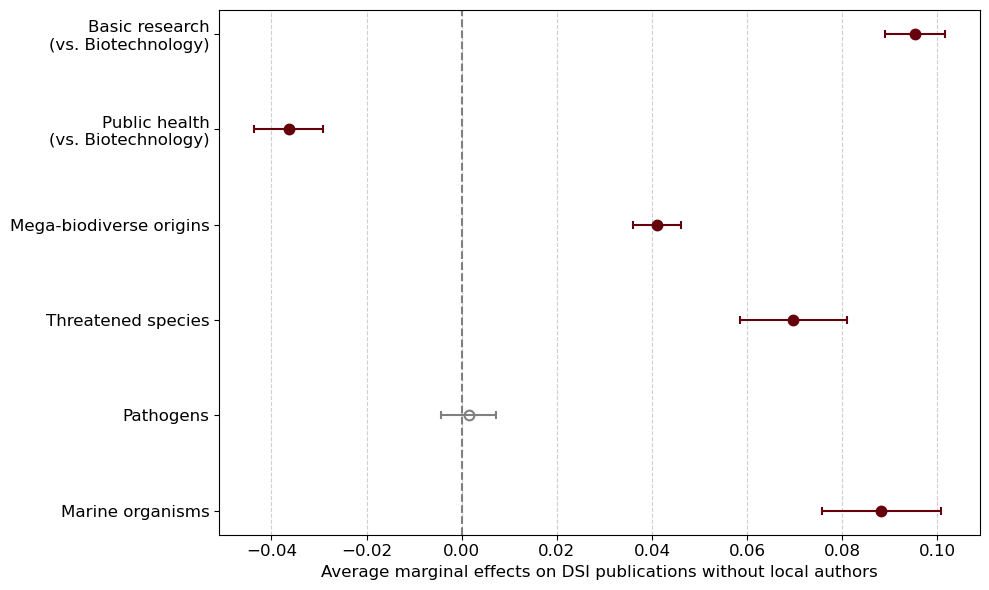

In [44]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

margins_extractivism_2 = models[0].get_margeff(at='zero').summary_frame()

# Define colors
color_extractivism = edge_colors_extr2.get(('G77', 'OECD', 0), colormap(0))  # Standard color for significant variables
color_non_significant = 'gray'  # Gray for non-significant variables

# Reverse order for better readability
reversed_order = list(reversed(margins_extractivism_2.index))

# Modify labels: Add a second line for the "(vs. Biotechnology)" part
reversed_order_labeled = [
    f"{label_dict.get(var, var)}\n(vs. Biotechnology)" if var in ['public_health', 'basic_research'] 
    else label_dict.get(var, var) 
    for var in reversed_order
]

plt.figure(figsize=(10, 6))

# Loop through variables to determine significance and plot accordingly
for var, label in zip(reversed_order, reversed_order_labeled):
    effect = margins_extractivism_2.loc[var, 'dy/dx']
    std_err = margins_extractivism_2.loc[var, 'Std. Err.']
    
    # Compute 95% confidence interval
    ci_lower = effect - 1.96 * std_err
    ci_upper = effect + 1.96 * std_err

    # Determine significance
    is_significant = not (ci_lower <= 0 <= ci_upper)
    
    # Style: filled circle if significant, hollow if not
    marker_style = 'o'
    face_color = color_extractivism if is_significant else 'none'  # Filled for significant, empty for non-significant
    edge_color = color_extractivism if is_significant else color_non_significant  # Gray edges for non-significant
    
    plt.errorbar(
        effect, label, xerr=std_err, fmt=marker_style, capsize=3, markersize=7,
        color=edge_color, markerfacecolor=face_color, markeredgewidth=1.5
    )

# Formatting
plt.axvline(0, color='grey', linestyle='--', linewidth=1.5)
plt.xlabel('Average marginal effects on DSI publications without local authors', fontsize=12)

# Adjust text sizes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()

# Save the plots
plt.savefig(path + "plots/marginal_effects_biotech_vs_publichealth_new.pdf")
plt.savefig(path + "plots/marginal_effects_biotech_vs_publichealth_new.png")

# Show the plot
plt.show()


### 3. Time analysis


In [100]:
df_regr_int['year_rescaled'] = df_regr_int['year_published'] - 2000

C:\Users\a494-nipw010\AppData\Local\Temp\ipykernel_20036\1187562701.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regr_int['year_rescaled'] = df_regr_int['year_published'] - 2000


#### 3.1. Linear effect

In [126]:
# Define outcome variables
outcomes = ['no_local_authors']
outcome_names = ['Without local authors']

# Define human-readable labels for predictors
label_dict = {
    'basic_research': 'Basic research',
    'biotechnology': 'Biotechnology',
    'public_health': 'Public health',
    'megadiv': 'Mega-biodiverse origins',
    'megadiv_g77': 'Mega-biodiverse (G77)',
    'megadiv_brics': 'Mega-biodiverse (BRICS)',
    'iucn_threatened': 'Threatened species',
    'pathogens': 'Pathogens',
    'marine': 'Marine organisms',
    'year_rescaled': 'Year'
}

# Initialize an empty list for models
models = []
nr = 0
for outcome in outcomes:
    if nr == 0:
        formula = f'{outcome} ~ basic_research + public_health + megadiv + iucn_threatened + pathogens + marine + year_rescaled'
        model = smf.logit(formula=formula, data=df_regr_int)
        results = model.fit()
        models.append(results)

# Create a summary table
summary = summary_col(models, stars=True, float_format="%.4f",
                      model_names=outcome_names, 
                      info_dict={
                          'N': lambda x: f"{int(x.nobs)}",
                          'Pseudo R2': lambda x: f"{x.prsquared:.4f}"
                      })

# Rename the index (row labels) of the summary table
summary.tables[0].rename(index=label_dict, inplace=True)

# Print updated summary table with labeled predictors
print(summary)


Optimization terminated successfully.
         Current function value: 0.636373
         Iterations 5

                        Without local authors
---------------------------------------------
Intercept               0.3789***            
                        (0.0412)             
Basic research          0.4684***            
                        (0.0317)             
Public health           -0.1927***           
                        (0.0323)             
Mega-biodiverse origins 0.1939***            
                        (0.0239)             
Threatened species      0.2164***            
                        (0.0516)             
Pathogens               -0.0631*             
                        (0.0267)             
Marine organisms        0.4241***            
                        (0.0571)             
Year                    -0.0799***           
                        (0.0022)             
N                       32762                
Pseudo R2              

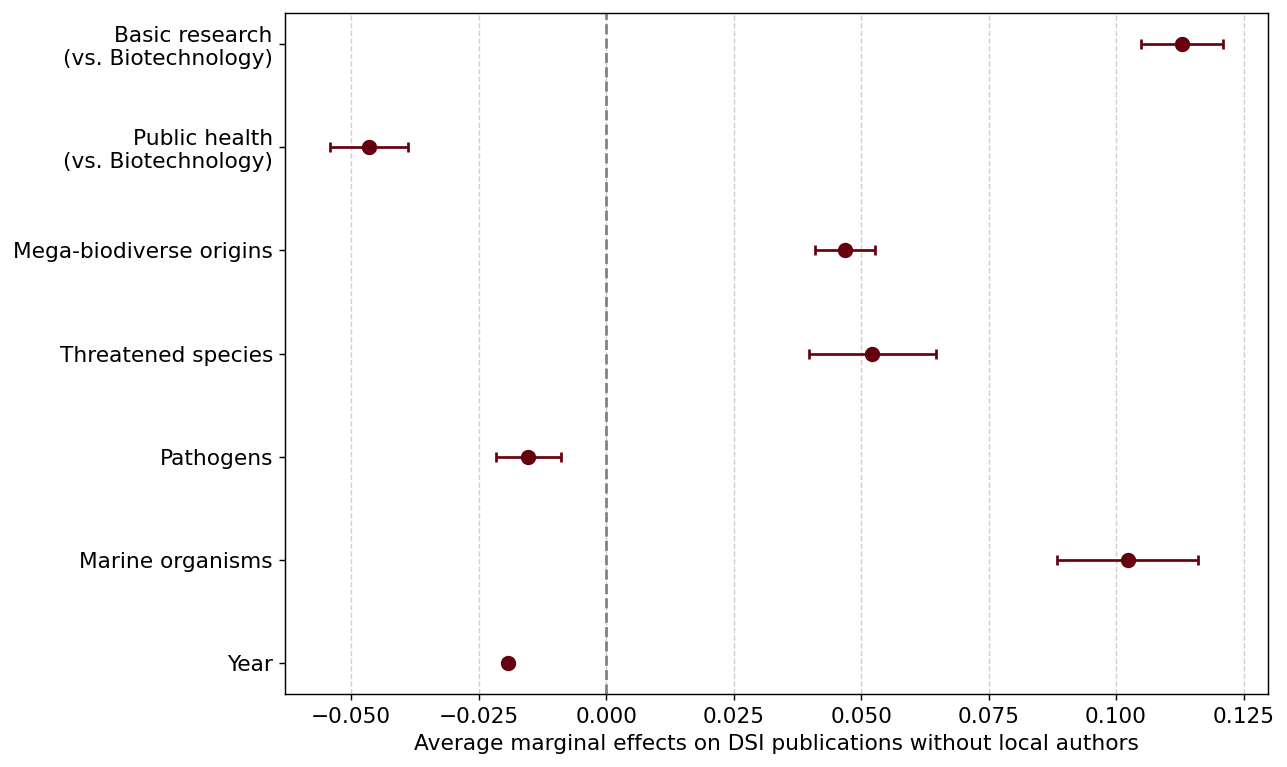

In [136]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

margins_extractivism_2 = models[0].get_margeff(at='zero').summary_frame()

# Define colors
color_extractivism = edge_colors_extr2.get(('G77', 'OECD', 0), colormap(0))  # Standard color for significant variables
color_non_significant = 'gray'  # Gray for non-significant variables

# Reverse order for better readability
reversed_order = list(reversed(margins_extractivism_2.index))

# Modify labels: Add a second line for the "(vs. Biotechnology)" part
reversed_order_labeled = [
    f"{label_dict.get(var, var)}\n(vs. Biotechnology)" if var in ['public_health', 'basic_research'] 
    else label_dict.get(var, var) 
    for var in reversed_order
]

plt.figure(figsize=(10, 6))

# Loop through variables to determine significance and plot accordingly
for var, label in zip(reversed_order, reversed_order_labeled):
    effect = margins_extractivism_2.loc[var, 'dy/dx']
    std_err = margins_extractivism_2.loc[var, 'Std. Err.']
    
    # Compute 95% confidence interval
    ci_lower = effect - 1.96 * std_err
    ci_upper = effect + 1.96 * std_err

    # Determine significance
    is_significant = not (ci_lower <= 0 <= ci_upper)
    
    # Style: filled circle if significant, hollow if not
    marker_style = 'o'
    face_color = color_extractivism if is_significant else 'none'  # Filled for significant, empty for non-significant
    edge_color = color_extractivism if is_significant else color_non_significant  # Gray edges for non-significant
    
    plt.errorbar(
        effect, label, xerr=std_err, fmt=marker_style, capsize=3, markersize=7,
        color=edge_color, markerfacecolor=face_color, markeredgewidth=1.5
    )

# Formatting
plt.axvline(0, color='grey', linestyle='--', linewidth=1.5)
plt.xlabel('Average marginal effects on DSI publications without local authors', fontsize=12)

# Adjust text sizes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()

# Save the plots
plt.savefig(path + "plots/marginal_effects_biotech_vs_publichealth_new_year.pdf")
plt.savefig(path + "plots/marginal_effects_biotech_vs_publichealth_new_year.png")

# Show the plot
plt.show()


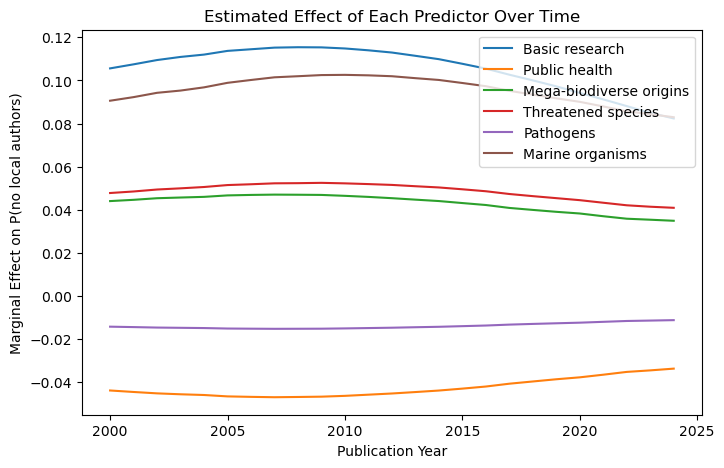

In [110]:
effects = {}
for var in ['basic_research', 'public_health', 'megadiv', 'iucn_threatened', 'pathogens', 'marine']:
    df_temp = df_regr_int.copy()
    df_temp['year_published'] = df_regr_int['year_published']
    df_temp[var] = 1
    pred1 = results.predict(df_temp)
    df_temp[var] = 0
    pred0 = results.predict(df_temp)
    effects[var] = (pred1 - pred0).groupby(df_temp['year_published']).mean()

plt.figure(figsize=(8,5))
for var, series in effects.items():
    plt.plot(series.index, series.values, label=label_dict.get(var, var))
plt.legend()
plt.title('Estimated Effect of Each Predictor Over Time')
plt.xlabel('Publication Year')
plt.ylabel('Marginal Effect on DSI publications without local authors)')

# Save the plots
plt.savefig(path + "plots/marginal_effects_over_time.pdf")
plt.savefig(path + "plots/marginal_effects_over_time.png")


plt.show()

In [140]:
#get confidence intervals? 

#### 3.2 Non-linear

In [116]:
# Define outcome variables
outcomes = ['no_local_authors']
outcome_names = ['Without local authors']

# Define human-readable labels for predictors
label_dict = {
    'basic_research': 'Basic research',
    'biotechnology': 'Biotechnology',
    'public_health': 'Public health',
    'megadiv': 'Mega-biodiverse origins',
    'megadiv_g77': 'Mega-biodiverse (G77)',
    'megadiv_brics': 'Mega-biodiverse (BRICS)',
    'iucn_threatened': 'Threatened species',
    'pathogens': 'Pathogens',
    'marine': 'Marine organisms',
    'year_published': 'Year'
}

# Initialize an empty list for models
models = []
nr = 0
for outcome in outcomes:
    if nr == 0:
        formula = f'{outcome} ~ (basic_research + public_health + megadiv + iucn_threatened + pathogens + marine) * C(year_published)'
        model = smf.logit(formula=formula, data=df_regr_int)
        results = model.fit()
        models.append(results)

# Create a summary table
summary = summary_col(models, stars=True, float_format="%.4f",
                      model_names=outcome_names, 
                      info_dict={
                          'N': lambda x: f"{int(x.nobs)}",
                          'Pseudo R2': lambda x: f"{x.prsquared:.4f}"
                      })

# Rename the index (row labels) of the summary table
summary.tables[0].rename(index=label_dict, inplace=True)

# Print updated summary table with labeled predictors
print(summary)


         Current function value: 0.630308
         Iterations: 35

                                          Without local authors
---------------------------------------------------------------
Intercept                                 0.1359               
                                          (0.3427)             
C(year_published)[T.2001]                 0.8852               
                                          (0.4623)             
C(year_published)[T.2002]                 0.1127               
                                          (0.4528)             
C(year_published)[T.2003]                 -0.2788              
                                          (0.4208)             
C(year_published)[T.2004]                 0.0452               
                                          (0.4042)             
C(year_published)[T.2005]                 -0.3363              
                                          (0.3887)             
C(year_published)[T.2006]            

C:\Users\a494-nipw010\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\a494-nipw010\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



                                               Without local authors
--------------------------------------------------------------------
Intercept                                      0.1359               
                                               (0.3427)             
Year: 2001 (vs 2000)                           0.8852               
                                               (0.4623)             
Year: 2002 (vs 2000)                           0.1127               
                                               (0.4528)             
Year: 2003 (vs 2000)                           -0.2788              
                                               (0.4208)             
Year: 2004 (vs 2000)                           0.0452               
                                               (0.4042)             
Year: 2005 (vs 2000)                           -0.3363              
                                               (0.3887)             
Year: 2006 (vs 2000)             

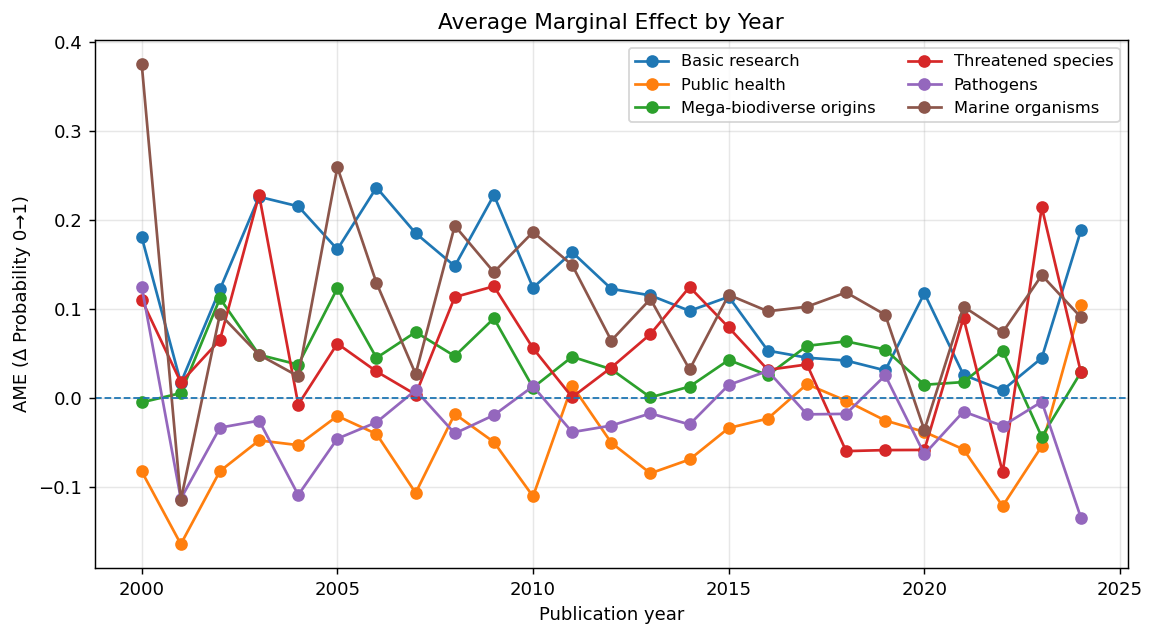

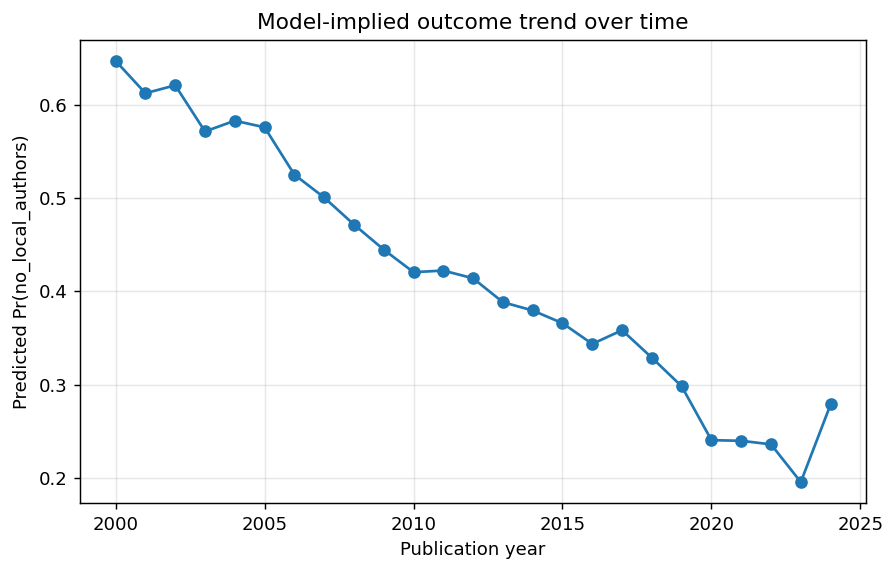

In [120]:
# =========================
# 0) Imports
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

plt.rcParams['figure.dpi'] = 130

# =========================
# 1) Config & clean copy
# =========================
df = df_regr_int.copy()  # avoid SettingWithCopyWarning by working on a true copy

year_col = 'year_published'      # change if your column is named differently
outcome  = 'no_local_authors'

X_vars = ['basic_research', 'public_health', 'megadiv',
          'iucn_threatened', 'pathogens', 'marine']

label_dict = {
    'basic_research': 'Basic research',
    'biotechnology': 'Biotechnology',
    'public_health': 'Public health',
    'megadiv': 'Mega-biodiverse origins',
    'megadiv_g77': 'Mega-biodiverse (G77)',
    'megadiv_brics': 'Mega-biodiverse (BRICS)',
    'iucn_threatened': 'Threatened species',
    'pathogens': 'Pathogens',
    'marine': 'Marine organisms',
}

# Ensure outcome is 0/1 integers (no NA)
df[outcome] = pd.to_numeric(df[outcome], errors='coerce').astype(float)
df = df[df[outcome].isin([0.0, 1.0])].copy()
df[outcome] = df[outcome].astype(int)

# Coerce year to numeric; drop rows with NA year or missing predictors
df[year_col] = pd.to_numeric(df[year_col], errors='coerce')

needed_cols = [outcome, year_col] + X_vars
df = df.dropna(subset=needed_cols).copy()

# IMPORTANT: cast year to *plain* numpy int64 (NOT pandas nullable Int64)
df[year_col] = df[year_col].astype('int64')

# Pick a clear reference year
ref_year = int(df[year_col].min())  # or set explicitly, e.g., ref_year = 2000

# =========================
# 2) Fit logit with categorical year + interactions
# =========================
X_block = ' + '.join(X_vars)
formula = (
    f"{outcome} ~ ({X_block}) * C({year_col}, Treatment(reference={ref_year}))"
)

model   = smf.logit(formula=formula, data=df)
results = model.fit(maxiter=200, disp=False)

# =========================
# 3) Summary table with nicer labels
# =========================
summary = summary_col([results], stars=True, float_format="%.4f",
                      model_names=['Without local authors'],
                      info_dict={
                          'N': lambda x: f"{int(x.nobs)}",
                          'Pseudo R2': lambda x: f"{x.prsquared:.4f}"
                      })

def rename_row_label(s: str) -> str:
    if s in label_dict:
        return label_dict[s]

    key_prefix = f"C({year_col}, Treatment(reference={ref_year}))"
    if s.startswith(key_prefix):
        # e.g. C(year_published, Treatment(reference=2000))[T.2001]
        yr = s.split('[T.')[-1].rstrip(']')
        return f"Year: {yr} (vs {ref_year})"

    if ':C(' in s or (f"C({year_col}" in s and ':' in s):
        parts = s.split(':')
        pretty_parts = []
        for p in parts:
            p = p.strip()
            if p in label_dict:
                pretty_parts.append(label_dict[p])
            elif p.startswith(key_prefix):
                yr = p.split('[T.')[-1].rstrip(']')
                pretty_parts.append(f"Year: {yr} (vs {ref_year})")
            else:
                pretty_parts.append(p)
        return ' × '.join(pretty_parts)

    return s

try:
    summary.tables[0].rename(index=lambda s: rename_row_label(str(s)), inplace=True)
except Exception:
    pass

print(summary)

# =========================
# 4) AME-by-year (binary 0→1 toggle), version-robust
# =========================
def ame_by_year(results, df, var, year_col):
    years = np.sort(df[year_col].unique())
    out = []
    for y in years:
        d = df.copy()
        d[year_col] = y  # lock year so year dummies/ints reflect this y

        d1 = d.copy(); d1[var] = 1
        d0 = d.copy(); d0[var] = 0

        p1 = results.predict(d1)
        p0 = results.predict(d0)

        out.append({'year': int(y), 'ame': float((p1 - p0).mean())})
    return pd.DataFrame(out)

effects = {var: ame_by_year(results, df, var, year_col) for var in X_vars}

# =========================
# 5) Overall predicted probability trend by year
# =========================
df['_pred_prob'] = results.predict(df)
avg_prob_by_year = (df
                    .groupby(year_col)['_pred_prob']
                    .mean()
                    .reset_index()
                    .rename(columns={year_col: 'year', '_pred_prob': 'pred_prob'}))

# =========================
# 6) Plots
# =========================
# (a) AME over time
plt.figure(figsize=(9, 5))
for var, df_eff in effects.items():
    df_eff = df_eff.sort_values('year')
    plt.plot(df_eff['year'], df_eff['ame'], marker='o', linewidth=1.5,
             label=label_dict.get(var, var))
plt.axhline(0, linewidth=1, linestyle='--')
plt.xlabel('Publication year')
plt.ylabel('AME (Δ Probability 0→1)')
plt.title('Average Marginal Effect by Year')
plt.legend(loc='best', ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# (b) Model-implied outcome probability over time
plt.figure(figsize=(7, 4.5))
avg_prob_by_year = avg_prob_by_year.sort_values('year')
plt.plot(avg_prob_by_year['year'], avg_prob_by_year['pred_prob'], marker='o', linewidth=1.5)
plt.xlabel('Publication year')
plt.ylabel('Predicted Pr(no_local_authors)')
plt.title('Model-implied outcome trend over time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4. Alternative models

In [12]:
#adjusted regression on full dataset with fixed effects
from statsmodels.iolib.summary2 import summary_col

# Define outcome variables
outcomes = ['extractivism_2']
outcome_names = ['Extractivism']

# Define human-readable labels for predictors
label_dict = {
    'basic_research': 'Basic research',
    'biotechnology': 'Biotechnology',
    'megadiv': 'Mega-biodiverse origins',
    'megadiv_g77': 'Mega-biodiverse (G77)',
    'megadiv_brics': 'Mega-biodiverse (BRICS)',
    'iucn_threatened': 'Threatened species',
    'pathogens': 'Pathogens',
    'marine': 'Marine organisms'
}

# Initialize an empty list for models
models = []

for outcome in outcomes:
        formula = f'{outcome} ~ basic_research + biotechnology + megadiv + iucn_threatened + pathogens + marine + sourcing_foreign'
        model = smf.logit(formula=formula, data=df_regr.fillna(0))
        results = model.fit(maxiter=1000, method='lbfgs')
        models.append(results)


# Create a summary table
summary = summary_col(models, stars=True, float_format="%.4f",
                      model_names=outcome_names, 
                      info_dict={
                          'N': lambda x: f"{int(x.nobs)}",
                          'Pseudo R2': lambda x: f"{x.prsquared:.4f}"
                      })

# Rename the index (row labels) of the summary table
summary.tables[0].rename(index=label_dict, inplace=True)

# Print updated summary table with labeled predictors
print(summary)



                        Extractivism
------------------------------------
Intercept               -18.6796    
                        (39.2478)   
Basic research          0.5872***   
                        (0.0284)    
Biotechnology           0.1621***   
                        (0.0315)    
Mega-biodiverse origins 0.1829***   
                        (0.0233)    
Threatened species      0.3112***   
                        (0.0503)    
Pathogens               0.0065      
                        (0.0259)    
Marine organisms        0.3934***   
                        (0.0558)    
sourcing_foreign        17.8510     
                        (39.2478)   
N                       94598       
Pseudo R2               0.4284      
Standard errors in parentheses.
* p<.05, ** p<.01, ***p<.001


In [34]:
#regulariezd regression on full dataset with fixed effects
import statsmodels.discrete.discrete_model as smd
from statsmodels.iolib.summary2 import summary_col

# Define outcome variables
outcomes = ['extractivism_2']
outcome_names = ['Extractivism']

# Define human-readable labels for predictors
label_dict = {
    'basic_research': 'Basic research',
    'biotechnology': 'Biotechnology',
    'megadiv': 'Mega-biodiverse origins',
    'megadiv_g77': 'Mega-biodiverse (G77)',
    'megadiv_brics': 'Mega-biodiverse (BRICS)',
    'iucn_threatened': 'Threatened species',
    'pathogens': 'Pathogens',
    'marine': 'Marine organisms'
}

# Initialize an empty list for models
models = []

# Define independent variables for manual logit fitting
independent_vars = [
    'basic_research', 'biotechnology', 'megadiv', 
    'iucn_threatened', 'pathogens', 'marine', 'sourcing_foreign'
]

for outcome in outcomes:
    # Prepare the data (drop NA and ensure predictors are numerical)
    df_clean = df_regr[independent_vars + [outcome]].fillna(0)

    # Define dependent and independent variables
    y = df_clean[outcome]
    X = df_clean[independent_vars]  # Predictor matrix

    # Add constant manually (statsmodels requires this)
    X = sm.add_constant(X)

    # Fit penalized logistic regression (Firth approximation using L1 penalty)
    model = smd.Logit(y, X).fit_regularized(method='l1', alpha=0.9)  # Small penalty to prevent separation
    models.append(model)

# Create a summary table
summary = summary_col(models, stars=True, float_format="%.4f",
                      model_names=outcome_names, 
                      info_dict={
                          'N': lambda x: f"{int(x.nobs)}",
                          'Pseudo R2': lambda x: f"{x.prsquared:.4f}"
                      })

# Rename the index (row labels) of the summary table
summary.tables[0].rename(index=label_dict, inplace=True)

# Print updated summary table with labeled predictors
print(summary)


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.2304192050034231
            Iterations: 163
            Function evaluations: 163
            Gradient evaluations: 163

                        Extractivism
------------------------------------
const                   -10.7504*** 
                        (0.7458)    
Basic research          0.5861***   
                        (0.0284)    
Biotechnology           0.1602***   
                        (0.0315)    
Mega-biodiverse origins 0.1826***   
                        (0.0233)    
Threatened species      0.3088***   
                        (0.0502)    
Pathogens               0.0051      
                        (0.0259)    
Marine organisms        0.3906***   
                        (0.0558)    
sourcing_foreign        9.9234***   
                        (0.7455)    
N                       94598       
Pseudo R2               0.4283      
Standard errors in parentheses.
* p<.05, ** p<

In [9]:
print(models[2].get_margeff(at = 'zero').summary())

        Logit Marginal Effects       
Dep. Variable:         extractivism_2
Method:                          dydx
At:                              zero
                     dy/dx    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
basic_research      0.0953      0.006     14.913      0.000       0.083       0.108
public_health      -0.0364      0.007     -5.001      0.000      -0.051      -0.022
megadiv             0.0410      0.005      8.117      0.000       0.031       0.051
iucn_threatened     0.0697      0.011      6.184      0.000       0.048       0.092
pathogens           0.0015      0.006      0.256      0.798      -0.010       0.013
marine              0.0882      0.012      7.064      0.000       0.064       0.113


In [60]:
betas

basic_research     0.587389
biotechnology      0.162247
megadiv            0.182969
iucn_threatened    0.310911
pathogens          0.006628
marine             0.393434
dtype: float64

In [54]:
import numpy as np
import pandas as pd

# Specify the values of the predictors for a specific combination
new_data = {
    'basic_research': 0,  # Example: set to 1
    'biotechnology': 1,   # Example: set to 0
    'megadiv': 0,         # Example: set to 0
    'iucn_threatened': 0, # Example: set to 0
    'pathogens': 0,       # Example: set to 0
    'marine': 0           # Example: set to 0
}

# Extract model coefficients (including the intercept)
coefficients = models[2].params  # model[0] is your fitted logistic regression model

# Extract the intercept (constant) and coefficients for the predictors
intercept = coefficients['Intercept']
betas = coefficients[1:]  # Coefficients for predictors

# Convert the new data into an array of predictor values
X_values = np.array([new_data[var] for var in new_data])

# Calculate the linear predictor (log-odds)
log_odds = intercept + np.dot(X_values, betas)

# Convert log-odds to predicted probability using the logistic function
predicted_prob = 1 / (1 + np.exp(-log_odds))

print(f"Predicted Probability of Extractivism: {predicted_prob:.4f}")


Predicted Probability of Extractivism: 0.3393


In [56]:
import numpy as np
import pandas as pd

# Specify the values of the predictors for a specific combination
new_data = {
    'basic_research': 0,  # Example: set to 1
    'biotechnology': 0,   # Example: set to 0
    'megadiv': 0,         # Example: set to 0
    'iucn_threatened': 0, # Example: set to 0
    'pathogens': 0,       # Example: set to 0
    'marine': 0           # Example: set to 0
}

# Extract model coefficients (including the intercept)
coefficients = models[2].params  # model[0] is your fitted logistic regression model

# Extract the intercept (constant) and coefficients for the predictors
intercept = coefficients['Intercept']
betas = coefficients[1:]  # Coefficients for predictors

# Convert the new data into an array of predictor values
X_values = np.array([new_data[var] for var in new_data])

# Calculate the linear predictor (log-odds)
log_odds = intercept + np.dot(X_values, betas)

# Convert log-odds to predicted probability using the logistic function
predicted_prob = 1 / (1 + np.exp(-log_odds))

print(f"Predicted Probability of Extractivism: {predicted_prob:.4f}")


Predicted Probability of Extractivism: 0.3039


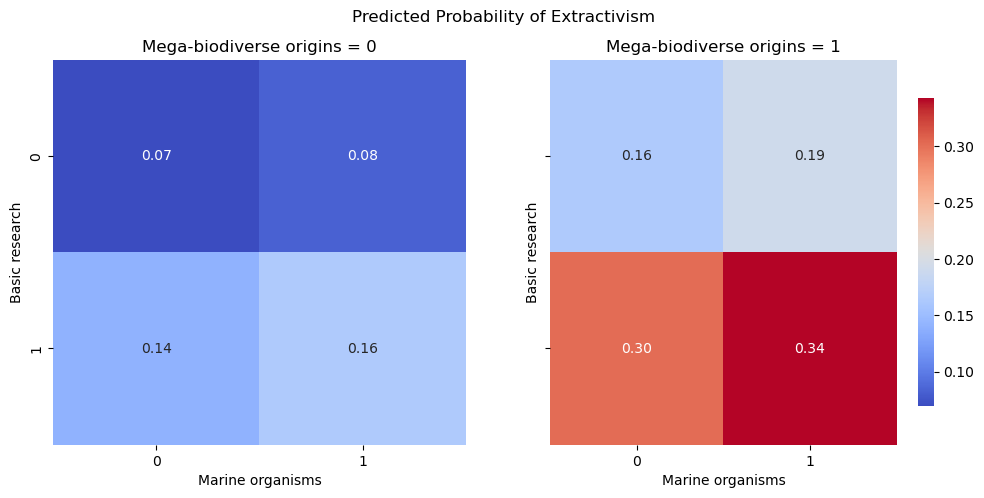

In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define a dictionary for more readable labels
label_dict = {
    'basic_research': 'Basic research',
    'marine': 'Marine organisms',
    'megadiv': 'Mega-biodiverse origins'
}

# Define variables for the heatmap axes
predictor_1 = 'basic_research'
predictor_2 = 'marine'
facet_var = 'megadiv'  # This variable will define different heatmaps

# Create all possible combinations of values
combinations = pd.DataFrame([
    {predictor_1: a, predictor_2: b, facet_var: c}
    for a in [0, 1] for b in [0, 1] for c in [0, 1]
])

# Add other fixed variables
combinations['biotechnology'] = 0  
combinations['iucn_threatened'] = 0  
combinations['pathogens'] = 0  

# Predict probabilities
combinations['predicted_prob'] = models[0].predict(combinations)

# Determine global min and max for consistent heatmap scale
vmin = combinations['predicted_prob'].min()
vmax = combinations['predicted_prob'].max()

# Create a figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, gridspec_kw={'width_ratios': [1, 1.05]})  # Adjust width for cbar

# Loop through each facet variable value
for i, value in enumerate([0, 1]):
    subset = combinations[combinations[facet_var] == value]
    heatmap_data = subset.pivot(index=predictor_1, columns=predictor_2, values='predicted_prob')

    # Show colorbar only on the last plot
    sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".2f", cbar=(i == 1), vmin=vmin, vmax=vmax, ax=axes[i],
                cbar_kws={"shrink": 0.8} if i == 1 else None)
    
    axes[i].set_title(f"{label_dict[facet_var]} = {value}")
    axes[i].set_xlabel(label_dict[predictor_2])
    axes[i].set_ylabel(label_dict[predictor_1])

plt.suptitle("Predicted Probability of Extractivism")
plt.show()
